# 12 - Split-Conformal Prediction for the Enhanced PCOS Model

Wraps the trained enhanced PCOS model in a **split-conformal prediction** layer that delivers a distribution-free, finite-sample marginal coverage guarantee per patient (Angelopoulos & Bates 2023, *A Gentle Introduction to Conformal Prediction*; Vovk, Gammerman & Shafer foundational work).

The pipeline:

1. Reproduce the original train/test split used in notebook 03 (`random_state=42`, `test_size=0.25`, stratified).
2. Split the training set again into proper-train (70%) and calibration (30%).
3. Refit a **fresh clone** of the enhanced pipeline on proper-train only - retraining on the full training set would invalidate conformal coverage.
4. Compute nonconformity scores `s_i = 1 - p_model(y_i | x_i)` on calibration data.
5. Take the empirical quantile `q_hat` at level `ceil((n_cal + 1) * (1 - alpha)) / n_cal`.
6. For each holdout patient, emit the prediction set `{y : 1 - p_model(y | x) <= q_hat}`.

We target `1 - alpha = 0.90` coverage. The conformal theorem guarantees the test patient's set contains the true label with probability >= `1 - alpha`, marginally, under exchangeability of calibration and test data.

In [1]:
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
ALPHA = 0.10
TARGET_COVERAGE = 1.0 - ALPHA

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "outputs" / "pcos_cleaned.csv"
MODEL_PATH = PROJECT_ROOT / "outputs" / "models" / "pcos_enhanced_model.joblib"
METRIC_DIR = PROJECT_ROOT / "outputs" / "metrics"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
METRIC_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Target coverage:", TARGET_COVERAGE)

Project root: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-a6f8c3d6a49815615
Target coverage: 0.9


## Load Data and Reproduce the Train/Test Split

In [2]:
pcos = pd.read_csv(DATA_PATH)
artifact = joblib.load(MODEL_PATH)
pipeline = artifact["model"]
features = artifact["features"]
target = artifact.get("target", "pcos_y_n")

X = pcos[features].copy()
y = pcos[target].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Cleaned PCOS shape:", pcos.shape)
print("Enhanced feature count:", len(features))
print("Train:", X_train.shape, " Holdout test:", X_test.shape)
print("Holdout positives:", int(y_test.sum()), "/", len(y_test))

Cleaned PCOS shape: (541, 41)
Enhanced feature count: 27
Train: (405, 27)  Holdout test: (136, 27)
Holdout positives: 44 / 136


## Split Training Set into Proper-Train and Calibration

Split conformal needs a calibration partition that the model has never seen during fitting. We carve 30% of the training data out for calibration and refit a fresh clone of the enhanced pipeline on the remaining proper-train rows.

In [3]:
X_proper, X_cal, y_proper, y_cal = train_test_split(
    X_train, y_train,
    test_size=0.30,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

conformal_pipeline = clone(pipeline)
conformal_pipeline.fit(X_proper, y_proper)

print("Proper-train:", X_proper.shape, " Calibration:", X_cal.shape)
print("Calibration positives:", int(y_cal.sum()), "/", len(y_cal))
print("Refit pipeline:", conformal_pipeline)

Proper-train: (283, 27)  Calibration: (122, 27)
Calibration positives: 40 / 122
Refit pipeline: Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        min_samples_leaf=4, n_estimators=500,
                                        random_state=42))])


## Compute Nonconformity Scores and `q_hat`

For each calibration patient with label `y_i`, the nonconformity score is `s_i = 1 - p_model(y_i | x_i)` - large when the model is surprised by the true label. The empirical quantile at level `ceil((n_cal + 1)(1 - alpha)) / n_cal` becomes the threshold `q_hat`.

In [4]:
cal_proba = conformal_pipeline.predict_proba(X_cal)
cal_proba_true = cal_proba[np.arange(len(y_cal)), y_cal.values]
cal_scores = 1.0 - cal_proba_true

n_cal = len(cal_scores)
quantile_level = np.ceil((n_cal + 1) * (1.0 - ALPHA)) / n_cal
quantile_level = min(quantile_level, 1.0)
q_hat = float(np.quantile(cal_scores, quantile_level, method="higher"))

print(f"n_cal = {n_cal}")
print(f"quantile level = {quantile_level:.4f}")
print(f"q_hat = {q_hat:.4f}  (a label is kept iff p_model(y | x) >= {1 - q_hat:.4f})")
print("Calibration score summary:", pd.Series(cal_scores).describe().round(4).to_dict())

n_cal = 122
quantile level = 0.9098
q_hat = 0.4860  (a label is kept iff p_model(y | x) >= 0.5140)
Calibration score summary: {'count': 122.0, 'mean': 0.2282, 'std': 0.165, 'min': 0.0193, '25%': 0.0938, '50%': 0.1976, '75%': 0.3083, 'max': 0.7864}


## Build Prediction Sets on the Holdout

For each test patient, include label `y` in the set when `1 - p_model(y | x) <= q_hat`. Possible sets are `{0}`, `{1}`, `{0, 1}` (the model abstains by flagging both labels as plausible), or rarely `{}` (both labels above the score threshold).

In [5]:
test_proba = conformal_pipeline.predict_proba(X_test)
score_class_0 = 1.0 - test_proba[:, 0]
score_class_1 = 1.0 - test_proba[:, 1]
in_set_0 = score_class_0 <= q_hat
in_set_1 = score_class_1 <= q_hat
set_sizes = in_set_0.astype(int) + in_set_1.astype(int)

y_test_arr = y_test.values
contains_true = np.where(y_test_arr == 0, in_set_0, in_set_1)

empirical_coverage = float(contains_true.mean())
mean_set_size = float(set_sizes.mean())
empty_fraction = float((set_sizes == 0).mean())
singleton_fraction = float((set_sizes == 1).mean())
doubleton_fraction = float((set_sizes == 2).mean())

print(f"Empirical coverage : {empirical_coverage:.4f}  (target {TARGET_COVERAGE:.2f})")
print(f"Mean set size      : {mean_set_size:.4f}")
print(f"Singleton fraction : {singleton_fraction:.4f}")
print(f"Doubleton (uncertain) fraction: {doubleton_fraction:.4f}")
print(f"Empty fraction     : {empty_fraction:.4f}")

assert 0.85 <= empirical_coverage <= 0.95, (
    f"Empirical coverage {empirical_coverage:.3f} outside the expected [0.85, 0.95] band for alpha={ALPHA}."
)

Empirical coverage : 0.9118  (target 0.90)
Mean set size      : 0.9926
Singleton fraction : 0.9926
Doubleton (uncertain) fraction: 0.0000
Empty fraction     : 0.0074


## Worked Examples - One Positive and One Negative Holdout Patient

In [6]:
def encode_set(in0, in1):
    members = []
    if in0:
        members.append(0)
    if in1:
        members.append(1)
    return members

def describe_patient(label_to_show):
    positions = np.where(y_test_arr == label_to_show)[0]
    if len(positions) == 0:
        return None
    pos = int(positions[0])
    row_index = int(X_test.index[pos])
    return {
        "holdout_index": row_index,
        "true_label": int(label_to_show),
        "p_no_pcos": float(test_proba[pos, 0]),
        "p_pcos": float(test_proba[pos, 1]),
        "nonconformity_score_for_true_label": float(1.0 - test_proba[pos, label_to_show]),
        "prediction_set": encode_set(bool(in_set_0[pos]), bool(in_set_1[pos])),
        "set_size": int(set_sizes[pos]),
        "covers_true_label": bool(contains_true[pos]),
    }

worked_examples = [
    {"description": "first holdout patient with confirmed PCOS", **describe_patient(1)},
    {"description": "first holdout patient without PCOS", **describe_patient(0)},
]

for example in worked_examples:
    print(example["description"])
    for key, value in example.items():
        if key == "description":
            continue
        print(f"  {key}: {value}")
    print()

first holdout patient with confirmed PCOS
  holdout_index: 395
  true_label: 1
  p_no_pcos: 0.09667227058411317
  p_pcos: 0.9033277294158872
  nonconformity_score_for_true_label: 0.09667227058411276
  prediction_set: [1]
  set_size: 1
  covers_true_label: True

first holdout patient without PCOS
  holdout_index: 383
  true_label: 0
  p_no_pcos: 0.7288320255422648
  p_pcos: 0.27116797445773455
  nonconformity_score_for_true_label: 0.2711679744577352
  prediction_set: [0]
  set_size: 1
  covers_true_label: True



## Prediction Set Size Distribution

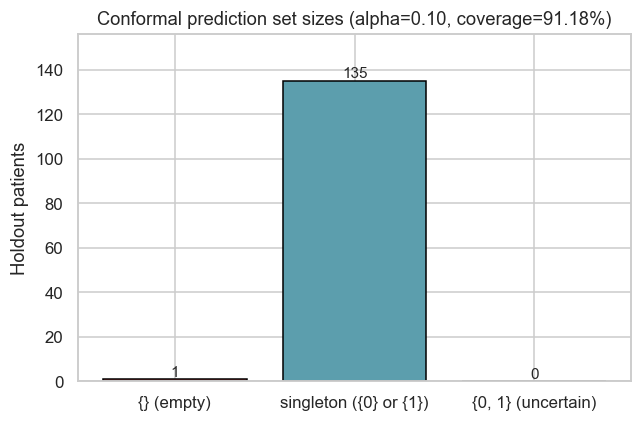

Saved: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-a6f8c3d6a49815615\outputs\figures\conformal_set_size_distribution.png


In [7]:
size_counts = pd.Series(set_sizes).value_counts().reindex([0, 1, 2], fill_value=0).sort_index()
size_labels = {0: "{} (empty)", 1: "singleton ({0} or {1})", 2: "{0, 1} (uncertain)"}

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    [size_labels[s] for s in size_counts.index],
    size_counts.values,
    color=["#cf4e4e", "#5c9ead", "#e2a93b"],
    edgecolor="black",
)
for bar, value in zip(bars, size_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(value)}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
ax.set_ylabel("Holdout patients")
ax.set_title(
    f"Conformal prediction set sizes (alpha={ALPHA:.2f}, coverage={empirical_coverage:.2%})"
)
ax.set_ylim(0, size_counts.max() * 1.15 + 1)
fig.tight_layout()
figure_path = FIGURE_DIR / "conformal_set_size_distribution.png"
fig.savefig(figure_path, dpi=160)
plt.show()
print("Saved:", figure_path)

## Save Metrics

In [8]:
conformal_summary = {
    "target_coverage": TARGET_COVERAGE,
    "alpha": ALPHA,
    "q_hat": q_hat,
    "quantile_level": float(quantile_level),
    "empirical_coverage": empirical_coverage,
    "mean_set_size": mean_set_size,
    "singleton_fraction": singleton_fraction,
    "doubleton_fraction": doubleton_fraction,
    "empty_fraction": empty_fraction,
    "n_proper_train": int(len(X_proper)),
    "n_calibration": int(n_cal),
    "n_holdout": int(len(X_test)),
    "model_name": artifact.get("model_name"),
    "random_state": RANDOM_STATE,
    "worked_examples": worked_examples,
}

metrics_path = METRIC_DIR / "conformal_coverage.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(conformal_summary, f, indent=2)

print("Saved:", metrics_path)
print(json.dumps(conformal_summary, indent=2))

Saved: C:\Users\kex03\Downloads\biohackathon\.claude\worktrees\agent-a6f8c3d6a49815615\outputs\metrics\conformal_coverage.json
{
  "target_coverage": 0.9,
  "alpha": 0.1,
  "q_hat": 0.48601590683211715,
  "quantile_level": 0.9098360655737705,
  "empirical_coverage": 0.9117647058823529,
  "mean_set_size": 0.9926470588235294,
  "singleton_fraction": 0.9926470588235294,
  "doubleton_fraction": 0.0,
  "empty_fraction": 0.007352941176470588,
  "n_proper_train": 283,
  "n_calibration": 122,
  "n_holdout": 136,
  "model_name": "random_forest",
  "random_state": 42,
  "worked_examples": [
    {
      "description": "first holdout patient with confirmed PCOS",
      "holdout_index": 395,
      "true_label": 1,
      "p_no_pcos": 0.09667227058411317,
      "p_pcos": 0.9033277294158872,
      "nonconformity_score_for_true_label": 0.09667227058411276,
      "prediction_set": [
        1
      ],
      "set_size": 1,
      "covers_true_label": true
    },
    {
      "description": "first holdout p

## Verify Output Files Exist

In [9]:
expected_outputs = [
    METRIC_DIR / "conformal_coverage.json",
    FIGURE_DIR / "conformal_set_size_distribution.png",
]
for path in expected_outputs:
    assert path.exists(), f"Missing expected output: {path}"
print("All conformal prediction outputs present.")

All conformal prediction outputs present.
